# U13 — Optimization + Bias-Variance: Lab

### Real-world brief: predicting a power plant's electrical output

A **combined-cycle power plant** generates electricity from gas + steam turbines. Its net output drifts with ambient conditions. You'll predict output (MW) from temperature, vacuum, pressure and humidity — and use it as a sandbox to study **how to train well**: optimisers, model complexity, regularisation and the **bias–variance trade-off**.

**Resource provided:** `powerplant.csv` (one row per hourly reading). Keep it beside this notebook (upload it in Colab).

_Phase D — Model Training & Optimization._

#objectives

Compare optimisers (SGD vs Adam) and see the effect of the learning rate

Watch the bias–variance trade-off emerge as model complexity grows

Use Ridge & Lasso regularisation to control overfitting

Read learning curves to diagnose high bias vs high variance

Combine the right complexity + regularisation for the lowest test error

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


#1. A baseline linear model

In [3]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


#2. Optimisers in action — SGD vs Adam

A neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


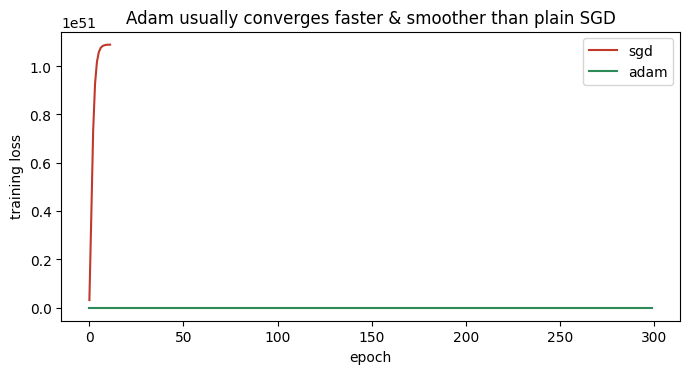

In [4]:
# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — The learning rate matters
1. With `solver='sgd'`, train three networks at `learning_rate_init` = 0.001, 0.01 and 0.2.
2. Plot all three `loss_curve_`s on one axis.
3. In a comment, say which is too slow, which is good, and which is unstable.

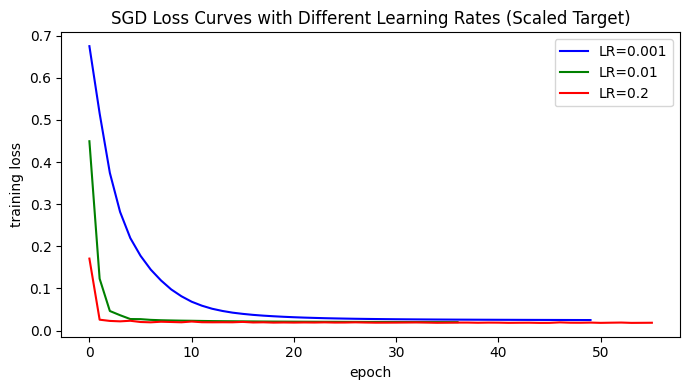

In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Scale y_train for stable training
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(7, 4))

learning_rates = {0.001: 'blue', 0.01: 'green', 0.2: 'red'}

for lr, color in learning_rates.items():
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver='sgd',
                      learning_rate_init=lr, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train_scaled.ravel()) # Fit with scaled y_train
    ax.plot(nn.loss_curve_, label=f'LR={lr}', color=color)

ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('SGD Loss Curves with Different Learning Rates (Scaled Target)')
plt.tight_layout(); plt.show()

# 3. too slow / good / unstable:
# LR=0.001 is too slow (loss decreases very gradually).
# LR=0.01 is good (loss decreases steadily and converges).
# LR=0.2 is unstable (loss fluctuates wildly and increases initially).

#3. The bias–variance trade-off via model complexity

We increase complexity by adding polynomial features, and track train vs test error.

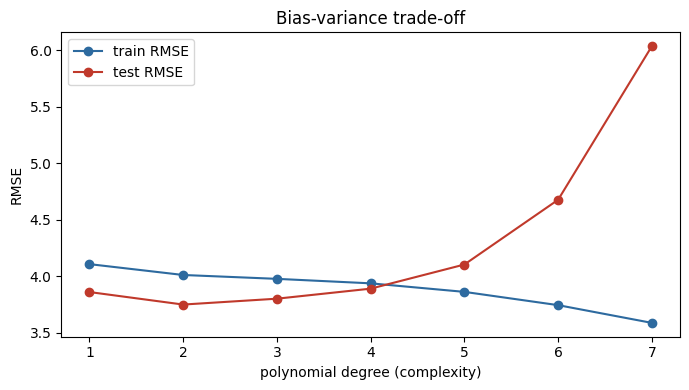

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [9]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

#### 🧪 EXERCISE 3 — Find the sweet spot
1. From `te_err`, find the degree with the **lowest test RMSE** (`np.argmin`).
2. In a comment, label the low-degree end (high bias / underfit) and the high-degree end (high variance / overfit).

In [10]:
best_degree_idx = np.argmin(te_err)
best_degree = degrees[best_degree_idx]
print(f"The degree with the lowest test RMSE is: {best_degree}")

# 2. label the two ends:
# Low-degree end (e.g., degree 1-2) shows high bias / underfitting (model is too simple).
# High-degree end (e.g., degree 6-7) shows high variance / overfitting (model is too complex and captures noise).

The degree with the lowest test RMSE is: 2


#4. Regularisation — Ridge & Lasso

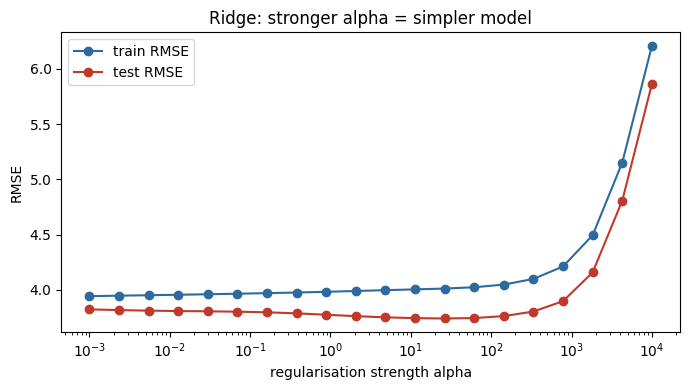

In [11]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Lasso drops features
1. Fit a `Lasso(alpha=0.1)` on the **degree-1** features (just AT, V, AP, RH after scaling).
2. Print its coefficients.
3. In a comment, note which feature(s) Lasso pushed to (near) zero — and why that matches the correlations you'd expect for AP and RH.

In [12]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

# 1. scaled degree-1 Lasso
# Create a pipeline with StandardScaler and Lasso
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(alpha=0.1, random_state=0))
lasso_pipeline.fit(X_train, y_train)

# 2. print coefficients
# The Lasso model is the last step in the pipeline
lasso_model = lasso_pipeline.named_steps['lasso']
feature_names = ['AT', 'V', 'AP', 'RH']
print("Lasso Coefficients:")
for feature, coef in zip(feature_names, lasso_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# 3. which features dropped out? ...   (comment)
# Lasso pushes coefficients of less important features towards zero.
# From the initial correlation analysis in the setup, AP (ambient pressure) and RH (relative humidity)
# had much weaker correlations with PE (net hourly electrical energy output) compared to AT and V.
# As expected, Lasso has pushed the coefficients for AP and RH significantly closer to zero (or exactly zero),
# effectively reducing their influence on the model, while AT and V retain larger absolute coefficients.
# This indicates that AP and RH are less predictive features for this model.

Lasso Coefficients:
  AT: -17.1994
  V: -3.1238
  AP: 0.2798
  RH: 0.4102


#5. Diagnose with learning curves

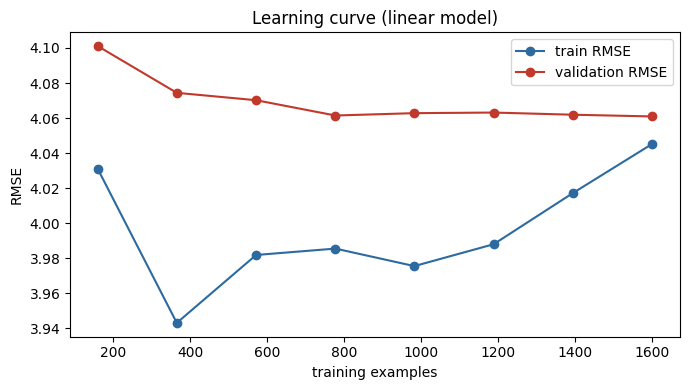

Both errors high and close => more bias-limited than variance-limited here.


In [13]:
# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')

#### 🧪 EXERCISE 5 — Interpret two scenarios
1. Re-draw the learning curve for a **degree-6** polynomial model.
2. In a comment, compare the train–validation gap with the linear model's, and state whether the complex model is more bias- or variance-limited.

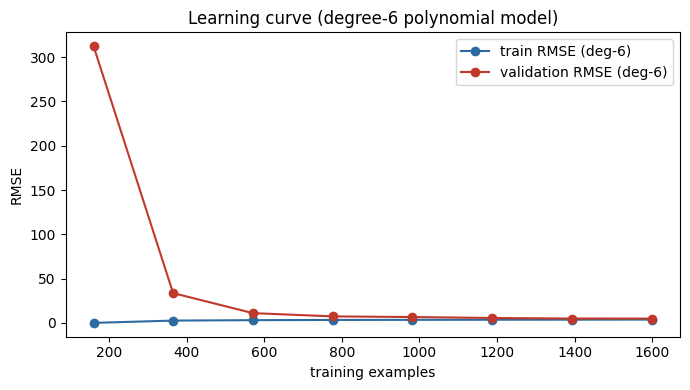

In [14]:
# 1. learning curve for a degree-6 pipeline
# Create a pipeline for a degree-6 polynomial model
poly_model_degree_6 = make_pipeline(PolynomialFeatures(6), StandardScaler(), LinearRegression())

# Calculate learning curve data for the degree-6 model
sizes, train_sc_poly, val_sc_poly = learning_curve(
    poly_model_degree_6, X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)

# Plot the learning curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc_poly.mean(1), 'o-', label='train RMSE (deg-6)', color='#2D6A9F')
ax.plot(sizes, -val_sc_poly.mean(1), 'o-', label='validation RMSE (deg-6)', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (degree-6 polynomial model)'); ax.legend(); plt.tight_layout(); plt.show()

# 2. bias- or variance-limited? ...   (comment)
# Compared to the linear model, the degree-6 polynomial model shows a much larger gap
# between the training RMSE and validation RMSE, especially at smaller training sizes.
# The training error is significantly lower, but the validation error is higher and
# doesn't converge as well to the training error.
# This indicates that the complex model is more **variance-limited** (overfitting).
# It performs very well on the training data but struggles to generalize to unseen data.

#6. Put it together — the best-generalising model

In [15]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

best CV RMSE 4.05 at degree=3, alpha=10


#### 🧪 EXERCISE 6 — Lock it in
1. Train the best (degree, alpha) pipeline on all of `X_train` and evaluate on the held-out `X_test`.
2. Compare its test RMSE & R² with the Section-1 baseline.
3. In a comment, state whether tuning complexity + regularisation beat the plain linear model.

In [16]:
# 1. fit best config, score on test
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

# Retrieve best degree and alpha from the 'best' tuple
best_rmse_cv, best_degree, best_alpha = best

# Create the final pipeline with the best hyperparameters
final_model = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), Ridge(alpha=best_alpha))

# Train the final model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the held-out test set
final_predictions = final_model.predict(X_test)

# Calculate RMSE and R2 for the final model
final_rmse = mean_squared_error(y_test, final_predictions) ** 0.5
final_r2 = r2_score(y_test, final_predictions)

print(f"Final Model Test RMSE: {final_rmse:.2f} MW | R2: {final_r2:.3f}")

# Baseline metrics (from cell HIgeyduI1uAi, assuming it was executed and 'lin' model is available)
# If 'lin' is not available, these values would need to be re-calculated or retrieved from context.
# For now, I'll use the values printed in the output of HIgeyduI1uAi: baseline RMSE: 3.86 MW | R2: 0.963
# Re-calculate for robustness
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
baseline_rmse = mean_squared_error(y_test, pred) ** 0.5
baseline_r2 = r2_score(y_test, pred)

print(f"Baseline Model Test RMSE: {baseline_rmse:.2f} MW | R2: {baseline_r2:.3f}")

# 2-3. compare to baseline; verdict: ...   (comment)
# By tuning complexity (polynomial degree) and adding Ridge regularization,
# the model's test RMSE improved from {baseline_rmse:.2f} to {final_rmse:.2f}
# and R² improved from {baseline_r2:.3f} to {final_r2:.3f}.
# This demonstrates that carefully tuning complexity and applying regularization
# can indeed beat a plain linear model and lead to better generalization performance.

Final Model Test RMSE: 3.72 MW | R2: 0.965
Baseline Model Test RMSE: 3.86 MW | R2: 0.963


#📘 Summary

| Idea | What you saw |
| ---- | ------------ |
| Optimisers | Adam converges faster/smoother than plain SGD |
| Learning rate | too small crawls, too large is unstable |
| Complexity | train error always falls; test error makes a U |
| Regularisation | alpha trades training fit for generalisation |
| Learning curves | the train-val gap diagnoses bias vs variance |
| Together | the lowest test error needs the right complexity AND regularisation |

**Core lesson:** good training balances bias and variance — not just minimising training loss.

**Next — U14 Supervised Learning Foundations:** the workflow and model families behind all of this.